In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


In [12]:
class CNNModel(nn.Module):
    def __init__(self, activation="relu", use_bn=False, dropout_rate=0.25, fc_neurons=128):
        super().__init__()

        self.act = self.get_activation(activation)

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2 = nn.BatchNorm2d(64) if use_bn else nn.Identity()

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout_rate)

        self.fc1 = nn.Linear(64 * 12 * 12, fc_neurons)
        self.fc_bn = nn.BatchNorm1d(fc_neurons) if use_bn else nn.Identity()

        self.out = nn.Linear(fc_neurons, 10)

    def get_activation(self, name):
        name = name.lower()
        if name == "sigmoid":
            return nn.Sigmoid()
        elif name == "tanh":
            return nn.Tanh()
        else:
            return nn.ReLU()

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)

        x = x.view(x.size(0), -1)
        x = self.act(self.fc_bn(self.fc1(x)))
        x = self.out(x)  # logits (no softmax)
        return x


In [13]:
class MLPModel(nn.Module):
    def __init__(self, layers=[256, 128], activation="relu", use_bn=True, dropout_rate=0.0):
        super().__init__()

        self.flatten = nn.Flatten()
        act = self.get_activation(activation)

        modules = []
        input_dim = 784

        for h in layers:
            modules.append(nn.Linear(input_dim, h))
            if use_bn:
                modules.append(nn.BatchNorm1d(h))
            modules.append(act)
            if dropout_rate > 0:
                modules.append(nn.Dropout(dropout_rate))
            input_dim = h

        modules.append(nn.Linear(input_dim, 10))
        self.net = nn.Sequential(*modules)

    def get_activation(self, name):
        name = name.lower()
        if name == "sigmoid":
            return nn.Sigmoid()
        elif name == "tanh":
            return nn.Tanh()
        else:
            return nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)  # logits


In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


In [15]:
def get_optimizer(name, params):
    name = name.lower()
    if name == "sgd":
        return optim.SGD(params, lr=0.01)
    elif name == "momentum":
        return optim.SGD(params, lr=0.01, momentum=0.9)
    else:
        return optim.Adam(params, lr=0.001)


def run_experiment(model_type="cnn", activation="relu", optimizer_name="adam",
                   epochs=10, use_bn=False, dropout_rate=0.25,
                   mlp_layers=[256, 128], cnn_fc_neurons=128):

    if model_type == "cnn":
        model = CNNModel(
            activation=activation,
            use_bn=use_bn,
            dropout_rate=dropout_rate,
            fc_neurons=cnn_fc_neurons
        ).to(device)
    else:
        model = MLPModel(
            layers=mlp_layers,
            activation=activation,
            use_bn=use_bn,
            dropout_rate=dropout_rate
        ).to(device)

    optimizer = get_optimizer(optimizer_name, model.parameters())
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for ep in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(f"Epoch {ep+1}/{epochs} | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f}")

    return history, history["test_acc"][-1]


In [16]:
task1_results = []
task1_histories = {}

for act in ["sigmoid", "tanh", "relu"]:
    print("\n==============================")
    print("Task 1: CNN Activation =", act, "(10 epochs)")
    print("==============================")

    hist, final_acc = run_experiment(
        model_type="cnn",
        activation=act,
        optimizer_name="adam",
        epochs=10,          # EXACT epochs
        use_bn=False,
        dropout_rate=0.25
    )

    task1_histories[act] = hist
    task1_results.append([f"CNN-{act}", act, "Adam", 10, final_acc])

df_task1 = pd.DataFrame(task1_results, columns=["Experiment","Activation","Optimizer","Epochs","Final Accuracy"])
df_task1



Task 1: CNN Activation = sigmoid (10 epochs)
Epoch 1/10 | Train Acc: 0.8288 | Test Acc: 0.9622
Epoch 2/10 | Train Acc: 0.9699 | Test Acc: 0.9805
Epoch 3/10 | Train Acc: 0.9802 | Test Acc: 0.9823
Epoch 4/10 | Train Acc: 0.9858 | Test Acc: 0.9854
Epoch 5/10 | Train Acc: 0.9885 | Test Acc: 0.9866
Epoch 6/10 | Train Acc: 0.9905 | Test Acc: 0.9887
Epoch 7/10 | Train Acc: 0.9928 | Test Acc: 0.9870
Epoch 8/10 | Train Acc: 0.9940 | Test Acc: 0.9893
Epoch 9/10 | Train Acc: 0.9953 | Test Acc: 0.9896
Epoch 10/10 | Train Acc: 0.9962 | Test Acc: 0.9896

Task 1: CNN Activation = tanh (10 epochs)
Epoch 1/10 | Train Acc: 0.9600 | Test Acc: 0.9832
Epoch 2/10 | Train Acc: 0.9822 | Test Acc: 0.9831
Epoch 3/10 | Train Acc: 0.9846 | Test Acc: 0.9803
Epoch 4/10 | Train Acc: 0.9861 | Test Acc: 0.9829
Epoch 5/10 | Train Acc: 0.9872 | Test Acc: 0.9845
Epoch 6/10 | Train Acc: 0.9874 | Test Acc: 0.9849
Epoch 7/10 | Train Acc: 0.9882 | Test Acc: 0.9827
Epoch 8/10 | Train Acc: 0.9883 | Test Acc: 0.9837
Epoch 9/10

,Experiment,Activation,Optimizer,Epochs,Final Accuracy
0,CNN-sigmoid,sigmoid,Adam,10,0.9896
1,CNN-tanh,tanh,Adam,10,0.9811
2,CNN-relu,relu,Adam,10,0.9915


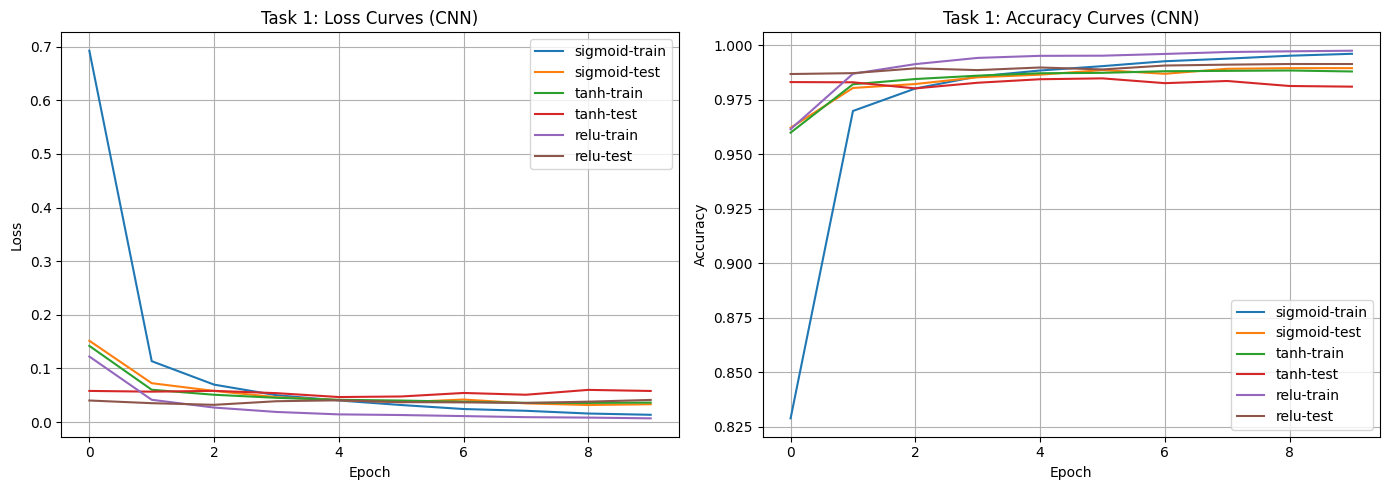

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for act in ["sigmoid", "tanh", "relu"]:
    plt.plot(task1_histories[act]["train_loss"], label=f"{act}-train")
    plt.plot(task1_histories[act]["test_loss"],  label=f"{act}-test")
plt.title("Task 1: Loss Curves (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for act in ["sigmoid", "tanh", "relu"]:
    plt.plot(task1_histories[act]["train_acc"], label=f"{act}-train")
    plt.plot(task1_histories[act]["test_acc"],  label=f"{act}-test")
plt.title("Task 1: Accuracy Curves (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Task 2**

In [19]:
task2_results = []
task2_histories = {}

for opt_name in ["sgd", "momentum", "adam"]:
    print("\n==============================")
    print("Task 2: Optimizer =", opt_name, "(10 epochs)")
    print("==============================")

    hist, final_acc = run_experiment(
        model_type="cnn",
        activation="relu",
        optimizer_name=opt_name,
        epochs=10,         # EXACT epochs
        use_bn=False,
        dropout_rate=0.25
    )

    task2_histories[opt_name] = hist
    task2_results.append([f"CNN-ReLU-{opt_name}", "ReLU", opt_name.upper(), 10, final_acc])

df_task2 = pd.DataFrame(task2_results, columns=["Experiment","Activation","Optimizer","Epochs","Final Accuracy"])
df_task2


Task 2: Optimizer = sgd (10 epochs)
Epoch 1/10 | Train Acc: 0.8787 | Test Acc: 0.9422
Epoch 2/10 | Train Acc: 0.9482 | Test Acc: 0.9593
Epoch 3/10 | Train Acc: 0.9637 | Test Acc: 0.9732
Epoch 4/10 | Train Acc: 0.9735 | Test Acc: 0.9774
Epoch 5/10 | Train Acc: 0.9783 | Test Acc: 0.9800
Epoch 6/10 | Train Acc: 0.9825 | Test Acc: 0.9829
Epoch 7/10 | Train Acc: 0.9840 | Test Acc: 0.9825
Epoch 8/10 | Train Acc: 0.9867 | Test Acc: 0.9847
Epoch 9/10 | Train Acc: 0.9889 | Test Acc: 0.9856
Epoch 10/10 | Train Acc: 0.9895 | Test Acc: 0.9855

Task 2: Optimizer = momentum (10 epochs)
Epoch 1/10 | Train Acc: 0.9419 | Test Acc: 0.9828
Epoch 2/10 | Train Acc: 0.9849 | Test Acc: 0.9817
Epoch 3/10 | Train Acc: 0.9901 | Test Acc: 0.9868
Epoch 4/10 | Train Acc: 0.9924 | Test Acc: 0.9888
Epoch 5/10 | Train Acc: 0.9941 | Test Acc: 0.9892
Epoch 6/10 | Train Acc: 0.9953 | Test Acc: 0.9870
Epoch 7/10 | Train Acc: 0.9964 | Test Acc: 0.9902
Epoch 8/10 | Train Acc: 0.9972 | Test Acc: 0.9903
Epoch 9/10 | Train A

,Experiment,Activation,Optimizer,Epochs,Final Accuracy
0,CNN-ReLU-sgd,ReLU,SGD,10,0.9855
1,CNN-ReLU-momentum,ReLU,MOMENTUM,10,0.9908
2,CNN-ReLU-adam,ReLU,ADAM,10,0.9912


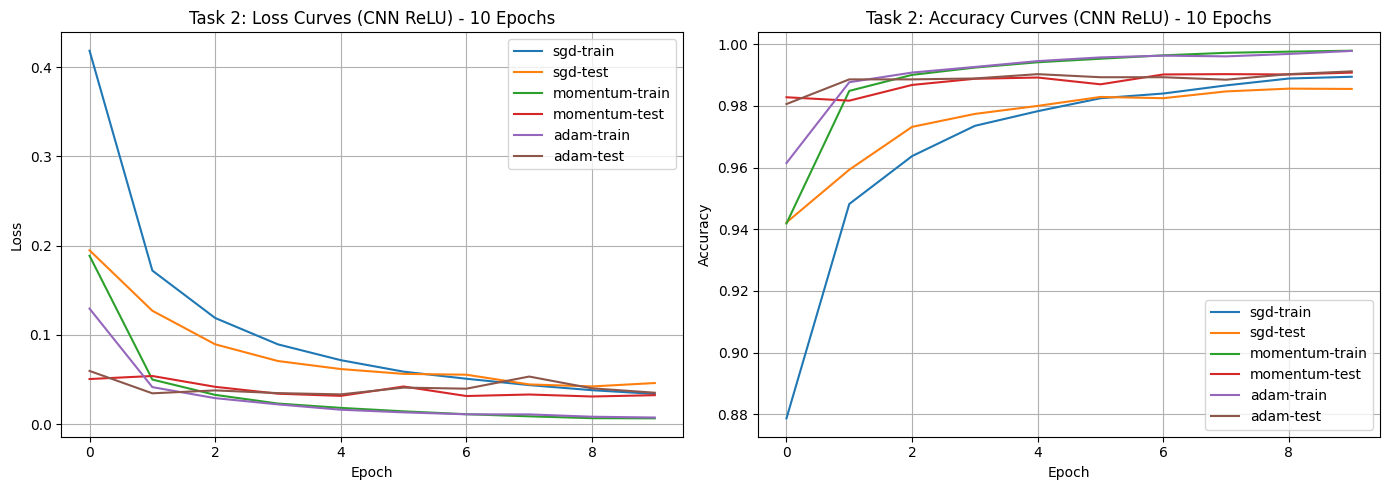

In [20]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for opt_name in ["sgd", "momentum", "adam"]:
    plt.plot(task2_histories[opt_name]["train_loss"], label=f"{opt_name}-train")
    plt.plot(task2_histories[opt_name]["test_loss"],  label=f"{opt_name}-test")
plt.title("Task 2: Loss Curves (CNN ReLU) - 10 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for opt_name in ["sgd", "momentum", "adam"]:
    plt.plot(task2_histories[opt_name]["train_acc"], label=f"{opt_name}-train")
    plt.plot(task2_histories[opt_name]["test_acc"],  label=f"{opt_name}-test")
plt.title("Task 2: Accuracy Curves (CNN ReLU) - 10 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
task3_configs = [
    ("No BN, No Dropout", False, 0.0),
    ("No BN, Dropout=0.1", False, 0.1),
    ("With BN, Dropout=0.25", True, 0.25)
]

task3_results = []
task3_histories = {}

for name, bn, dr in task3_configs:
    print("\n==============================")
    print("Task 3 Scenario:", name, "(10 epochs)")
    print("==============================")

    hist, final_acc = run_experiment(
        model_type="cnn",
        activation="relu",
        optimizer_name="adam",
        epochs=10,
        use_bn=bn,
        dropout_rate=dr
    )

    task3_histories[name] = hist
    task3_results.append([name, "ReLU", "Adam", 10, final_acc])

df_task3 = pd.DataFrame(task3_results, columns=["Experiment","Activation","Optimizer","Epochs","Final Accuracy"])
df_task3


Task 3 Scenario: No BN, No Dropout (10 epochs)
Epoch 1/10 | Train Acc: 0.9620 | Test Acc: 0.9857
Epoch 2/10 | Train Acc: 0.9884 | Test Acc: 0.9881
Epoch 3/10 | Train Acc: 0.9925 | Test Acc: 0.9860
Epoch 4/10 | Train Acc: 0.9947 | Test Acc: 0.9875
Epoch 5/10 | Train Acc: 0.9961 | Test Acc: 0.9880
Epoch 6/10 | Train Acc: 0.9965 | Test Acc: 0.9880
Epoch 7/10 | Train Acc: 0.9974 | Test Acc: 0.9887
Epoch 8/10 | Train Acc: 0.9976 | Test Acc: 0.9889
Epoch 9/10 | Train Acc: 0.9984 | Test Acc: 0.9889
Epoch 10/10 | Train Acc: 0.9977 | Test Acc: 0.9911

Task 3 Scenario: No BN, Dropout=0.1 (10 epochs)
Epoch 1/10 | Train Acc: 0.9646 | Test Acc: 0.9843
Epoch 2/10 | Train Acc: 0.9874 | Test Acc: 0.9855
Epoch 3/10 | Train Acc: 0.9922 | Test Acc: 0.9877
Epoch 4/10 | Train Acc: 0.9948 | Test Acc: 0.9886
Epoch 5/10 | Train Acc: 0.9955 | Test Acc: 0.9890
Epoch 6/10 | Train Acc: 0.9965 | Test Acc: 0.9894
Epoch 7/10 | Train Acc: 0.9974 | Test Acc: 0.9886
Epoch 8/10 | Train Acc: 0.9968 | Test Acc: 0.9887
Ep

,Experiment,Activation,Optimizer,Epochs,Final Accuracy
0,"No BN, No Dropout",ReLU,Adam,10,0.9911
1,"No BN, Dropout=0.1",ReLU,Adam,10,0.9879
2,"With BN, Dropout=0.25",ReLU,Adam,10,0.9906


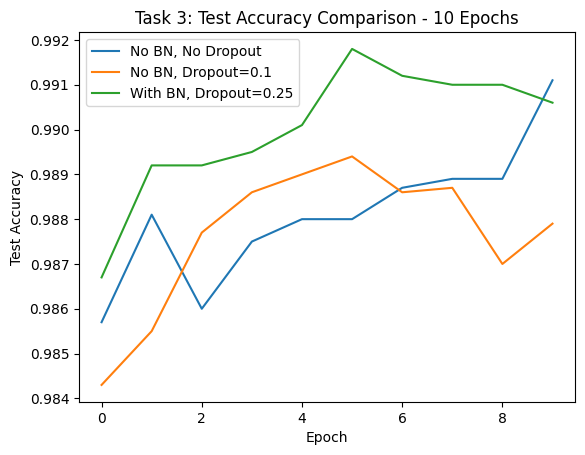

In [22]:
plt.figure()
for name, _, _ in task3_configs:
    plt.plot(task3_histories[name]["test_acc"], label=name)
plt.title("Task 3: Test Accuracy Comparison - 10 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.show()

In [23]:
required_results = []

# CNN-1: FC=128, Adam, 10 epochs
print("\n==============================")
print("Running REQUIRED CNN-1 (10 epochs)")
print("==============================")

_, acc = run_experiment(
    model_type="cnn",
    activation="relu",
    optimizer_name="adam",
    epochs=10,              # EXACT
    use_bn=False,
    dropout_rate=0.25,
    cnn_fc_neurons=128
)
required_results.append(["CNN-1", "128", "Adam", 10, acc])


# MLP-1: 512-256-128, SGD, 20 epochs
print("\n==============================")
print("Running REQUIRED MLP-1 (20 epochs)")
print("==============================")

_, acc = run_experiment(
    model_type="mlp",
    activation="relu",
    optimizer_name="sgd",
    epochs=20,              # EXACT
    use_bn=True,
    dropout_rate=0.0,
    mlp_layers=[512, 256, 128]
)
required_results.append(["MLP-1", "512-256-128", "SGD", 20, acc])


# MLP-2: 256, Adam, 15 epochs
print("\n==============================")
print("Running REQUIRED MLP-2 (15 epochs)")
print("==============================")

_, acc = run_experiment(
    model_type="mlp",
    activation="relu",
    optimizer_name="adam",
    epochs=15,
    use_bn=True,
    dropout_rate=0.0,
    mlp_layers=[256]
)
required_results.append(["MLP-2", "256", "Adam", 15, acc])


df_required = pd.DataFrame(required_results, columns=["Model","FC layer","Optimizer","Epochs","Accuracy"])
df_required


Running REQUIRED CNN-1 (10 epochs)
Epoch 1/10 | Train Acc: 0.9635 | Test Acc: 0.9863
Epoch 2/10 | Train Acc: 0.9873 | Test Acc: 0.9876
Epoch 3/10 | Train Acc: 0.9909 | Test Acc: 0.9889
Epoch 4/10 | Train Acc: 0.9938 | Test Acc: 0.9902
Epoch 5/10 | Train Acc: 0.9947 | Test Acc: 0.9891
Epoch 6/10 | Train Acc: 0.9960 | Test Acc: 0.9891
Epoch 7/10 | Train Acc: 0.9965 | Test Acc: 0.9891
Epoch 8/10 | Train Acc: 0.9972 | Test Acc: 0.9892
Epoch 9/10 | Train Acc: 0.9969 | Test Acc: 0.9900
Epoch 10/10 | Train Acc: 0.9980 | Test Acc: 0.9922

Running REQUIRED MLP-1 (20 epochs)
Epoch 1/20 | Train Acc: 0.9068 | Test Acc: 0.9589
Epoch 2/20 | Train Acc: 0.9620 | Test Acc: 0.9725
Epoch 3/20 | Train Acc: 0.9742 | Test Acc: 0.9767
Epoch 4/20 | Train Acc: 0.9814 | Test Acc: 0.9774
Epoch 5/20 | Train Acc: 0.9862 | Test Acc: 0.9775
Epoch 6/20 | Train Acc: 0.9902 | Test Acc: 0.9794
Epoch 7/20 | Train Acc: 0.9927 | Test Acc: 0.9807
Epoch 8/20 | Train Acc: 0.9943 | Test Acc: 0.9796
Epoch 9/20 | Train Acc: 0.9

,Model,FC layer,Optimizer,Epochs,Accuracy
0,CNN-1,128,Adam,10,0.9922
1,MLP-1,512-256-128,SGD,20,0.9821
2,MLP-2,256,Adam,15,0.9816


In [24]:
example_results = []
example_histories = {}

# 1) Sigmoid + SGD (10 epochs)
print("\n==============================")
print("Example Exp 1: Sigmoid + SGD (10 epochs)")
print("==============================")

hist, acc = run_experiment(
    model_type="cnn",
    activation="sigmoid",
    optimizer_name="sgd",
    epochs=10,              # EXACT
    use_bn=False,
    dropout_rate=0.25
)
example_histories["Sigmoid+SGD"] = hist
example_results.append([1, "Sigmoid", "SGD", 10, acc])


# 2) ReLU + SGD (10 epochs)
print("\n==============================")
print("Example Exp 2: ReLU + SGD (10 epochs)")
print("==============================")

hist, acc = run_experiment(
    model_type="cnn",
    activation="relu",
    optimizer_name="sgd",
    epochs=10,              # EXACT
    use_bn=False,
    dropout_rate=0.25
)
example_histories["ReLU+SGD"] = hist
example_results.append([2, "ReLU", "SGD", 10, acc])


# 3) ReLU + Adam (10 epochs)
print("\n==============================")
print("Example Exp 3: ReLU + Adam (10 epochs)")
print("==============================")

hist, acc = run_experiment(
    model_type="cnn",
    activation="relu",
    optimizer_name="adam",
    epochs=10,              # EXACT
    use_bn=False,
    dropout_rate=0.25
)
example_histories["ReLU+Adam"] = hist
example_results.append([3, "ReLU", "Adam", 10, acc])


df_example = pd.DataFrame(example_results, columns=["Experiment","Activation","Optimizer","Epochs","Final Accuracy"])
df_example



Example Exp 1: Sigmoid + SGD (10 epochs)
Epoch 1/10 | Train Acc: 0.1176 | Test Acc: 0.0958
Epoch 2/10 | Train Acc: 0.1939 | Test Acc: 0.5880
Epoch 3/10 | Train Acc: 0.5386 | Test Acc: 0.7207
Epoch 4/10 | Train Acc: 0.7927 | Test Acc: 0.8490
Epoch 5/10 | Train Acc: 0.8568 | Test Acc: 0.8772
Epoch 6/10 | Train Acc: 0.8784 | Test Acc: 0.8929
Epoch 7/10 | Train Acc: 0.8884 | Test Acc: 0.9012
Epoch 8/10 | Train Acc: 0.8963 | Test Acc: 0.9053
Epoch 9/10 | Train Acc: 0.9018 | Test Acc: 0.9113
Epoch 10/10 | Train Acc: 0.9068 | Test Acc: 0.9132

Example Exp 2: ReLU + SGD (10 epochs)
Epoch 1/10 | Train Acc: 0.8734 | Test Acc: 0.8973
Epoch 2/10 | Train Acc: 0.9472 | Test Acc: 0.9635
Epoch 3/10 | Train Acc: 0.9637 | Test Acc: 0.9747
Epoch 4/10 | Train Acc: 0.9723 | Test Acc: 0.9781
Epoch 5/10 | Train Acc: 0.9787 | Test Acc: 0.9809
Epoch 6/10 | Train Acc: 0.9828 | Test Acc: 0.9819
Epoch 7/10 | Train Acc: 0.9845 | Test Acc: 0.9830
Epoch 8/10 | Train Acc: 0.9866 | Test Acc: 0.9845
Epoch 9/10 | Train

,Experiment,Activation,Optimizer,Epochs,Final Accuracy
0,1,Sigmoid,SGD,10,0.9132
1,2,ReLU,SGD,10,0.9857
2,3,ReLU,Adam,10,0.9875


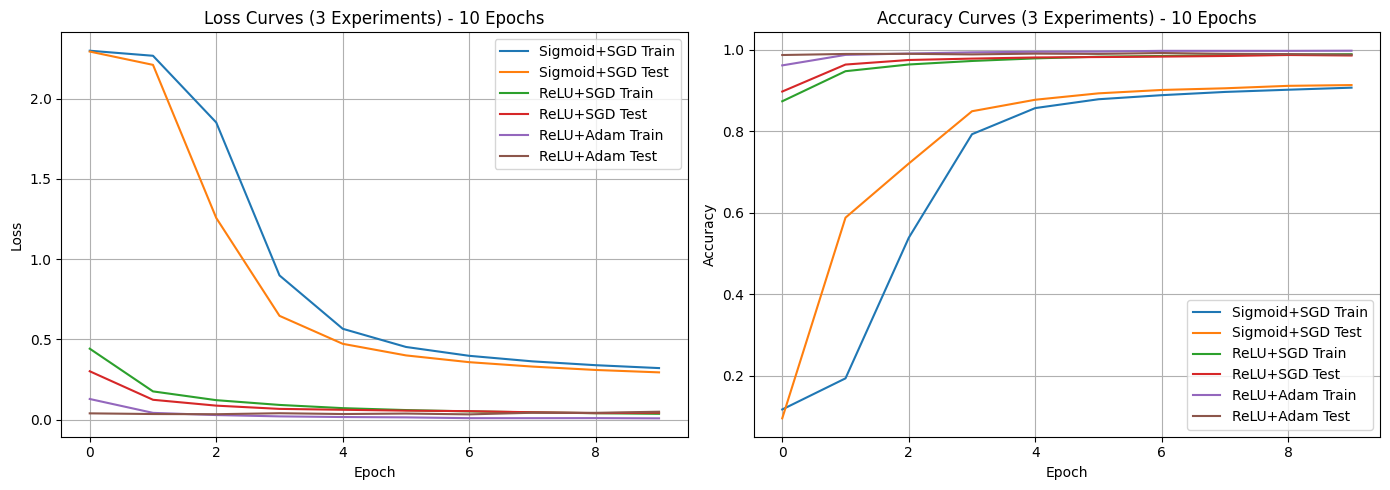

In [27]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, hist in example_histories.items():
    plt.plot(hist["train_loss"], label=f"{name} Train")
    plt.plot(hist["test_loss"],  label=f"{name} Test")
plt.title("Loss Curves (3 Experiments) - 10 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, hist in example_histories.items():
    plt.plot(hist["train_acc"], label=f"{name} Train")
    plt.plot(hist["test_acc"],  label=f"{name} Test")
plt.title("Accuracy Curves (3 Experiments) - 10 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
final_comparison_table = pd.concat([df_task1, df_task2, df_task3, df_example], ignore_index=True)
final_comparison_table

,Experiment,Activation,Optimizer,Epochs,Final Accuracy
0,CNN-sigmoid,sigmoid,Adam,10,0.9896
1,CNN-tanh,tanh,Adam,10,0.9811
2,CNN-relu,relu,Adam,10,0.9915
3,CNN-ReLU-sgd,ReLU,SGD,10,0.9855
4,CNN-ReLU-momentum,ReLU,MOMENTUM,10,0.9908
5,CNN-ReLU-adam,ReLU,ADAM,10,0.9912
6,"No BN, No Dropout",ReLU,Adam,10,0.9911
7,"No BN, Dropout=0.1",ReLU,Adam,10,0.9879
8,"With BN, Dropout=0.25",ReLU,Adam,10,0.9906
9,1,Sigmoid,SGD,10,0.9132
